In [96]:
#Import Libraries
import pandas as pd

In [97]:
#Load Dataset
df = pd.read_csv("insurance.csv")

In [98]:
#Display first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [99]:
#Check number of rows and columns in the dataset
df.shape

(1338, 7)

In [100]:
#Check data types
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [101]:
#Check missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [102]:
#Display column names
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [103]:
#Check for duplicated Values
df.duplicated().sum()

np.int64(1)

In [104]:
#Remove Duplicates
df = df.drop_duplicates()

In [203]:
X = pd.get_dummies(X, drop_first=True)
X = X.dropna()
X = X.loc[:, ~X.columns.duplicated()]
X = X.loc[:, X.nunique() > 1]
X = X.astype(float)

In [105]:
#Summary Stats
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


### Evaluation of Dataset Suitability for Linear Regression

Linear regression is a supervised machine learning algorithm used to model the relationship between a dependent variable and one or more independent variables. In this dataset, the variable charges represents the dependent variable, while the remaining variables such as age, bmi, children, sex, smoker, and region act as independent variables.

This dataset is suitable for applying a linear regression algorithm based on the following evaluation criteria:
1. Presence of a Continuous Dependent Variable
2. Availability of Numerical Independent Variables
3. Dataset Size Adequacy
4. Absence of Significant Missing Values
5. Linear Relationship Between Variables
6. Low Multicollinearity Between Independent Variables

Based on the evaluation criteria, the insurance dataset is suitable for applying a linear regression algorithm. Therefore, linear regression can be effectively applied to predict insurance charges based on demographic and health-related features.

(James et al., 2021)

### Exploratory Data Analysis (EDA) Plan
Exploratory Data Analysis (EDA) is performed to understand the structure, quality, and patterns within the dataset before applying machine learning algorithms. The purpose of EDA is to ensure that the data is clean, consistent, and suitable for analysis and predictive modeling.

The following steps outline the planned approach to ensure the dataset is clean and well understood.
1. Load the Dataset and Inspect Basic Structure
2. Understand Data Types
3. Check for Missing Values
4. Identify Duplicate Records
5. Generate Summary Statistics

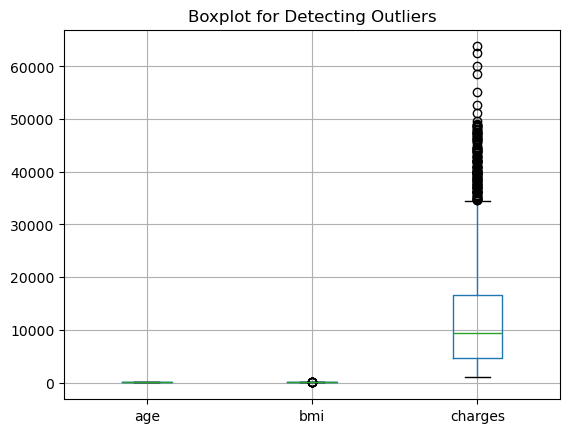

In [106]:
import matplotlib.pyplot as plt

# Boxplot for numerical variables
df[['age', 'bmi', 'charges']].boxplot()

plt.title("Boxplot for Detecting Outliers")
plt.show()

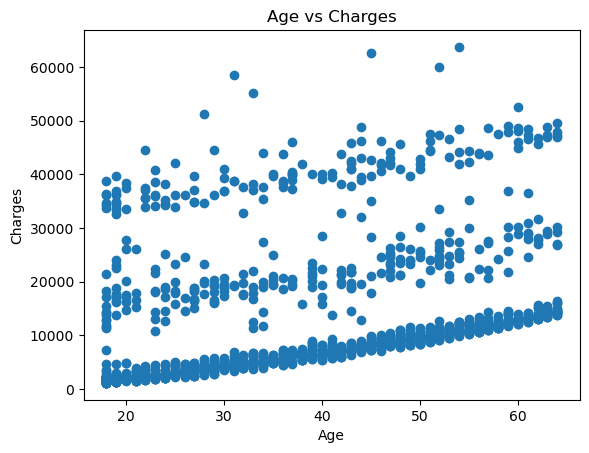

In [107]:
# Scatter plot
plt.scatter(df['age'], df['charges'])

plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

In [108]:
import numpy as np

# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Display correlation
corr_matrix

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


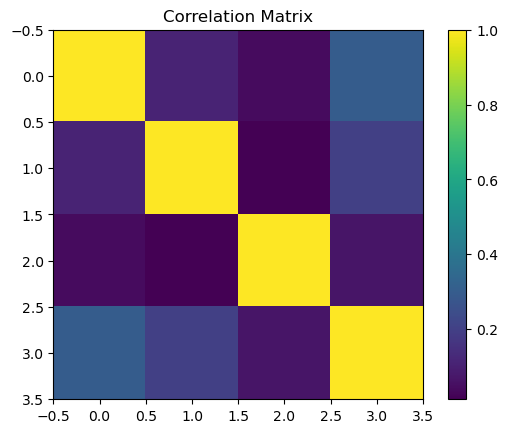

In [109]:
import matplotlib.pyplot as plt

plt.imshow(corr_matrix)
plt.title("Correlation Matrix")
plt.colorbar()
plt.show()

In [110]:
# Value counts
df['sex'].value_counts()

df['smoker'].value_counts()

df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [111]:
#Convert categorical variables to numerical
df_encoded=pd.get_dummies(df, drop_first=True)

In [129]:
# Define X and Y

X = df_encoded.drop('charges', axis=1)
Y = df_encoded['charges']

In [131]:
# Correlation with target variable
correlation = df_encoded.corr(numeric_only=True)

correlation['charges'].sort_values(ascending=False)

charges             1.000000
smoker_yes          0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex_male            0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64

### Model Training
This involves fitting a machine learning algorithm to the dataset so that it can learn relationships between independent variables and the dependent variable. In this one particular a Linear Regression model will be used to predict insurance charges based on selected features.

In [141]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display shapes
X_train.shape, X_test.shape

((1069, 8), (268, 8))

In [142]:
from sklearn.linear_model import LinearRegression

# Initialize model
model = LinearRegression()

In [143]:
fit_intercept = True

In [144]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [145]:
n_jobs = None

In [146]:
# Train model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [147]:
# Make predictions
y_pred = model.predict(X_test)

The linear regression model will be trained using carefully selected hyperparameters to ensure reliable and accurate predictions. The dataset will first be divided into training and testing sets to prevent overfitting. Hyperparameters such as fit_intercept, random_state, and test_size will be used to control model behavior and ensure consistent results.

This structured training approach ensures that the model is robust, reproducible, and suitable for predicting insurance charges.

### Model Interpretation and Evaluation

In [148]:
from sklearn.metrics import r2_score

# Calculate R² score
r2 = r2_score(y_test, y_pred)

print("R-squared:", r2)

R-squared: 0.8069287081198013


In [149]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 4177.045561036322


In [150]:
from sklearn.metrics import mean_squared_error

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 35478020.67523558


In [151]:
import numpy as np

# Calculate RMSE
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 5956.342894363585


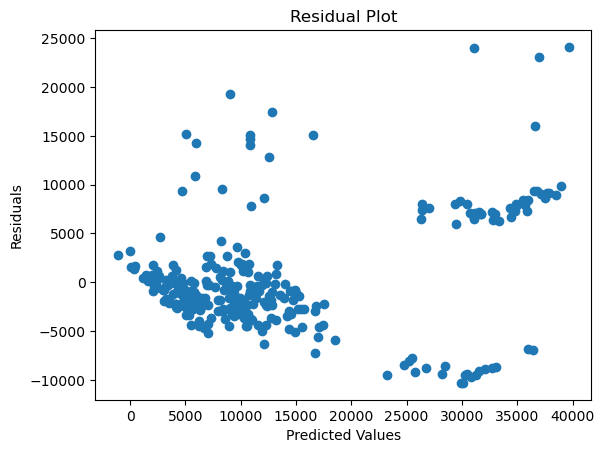

In [152]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.scatter(y_pred, residuals)

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

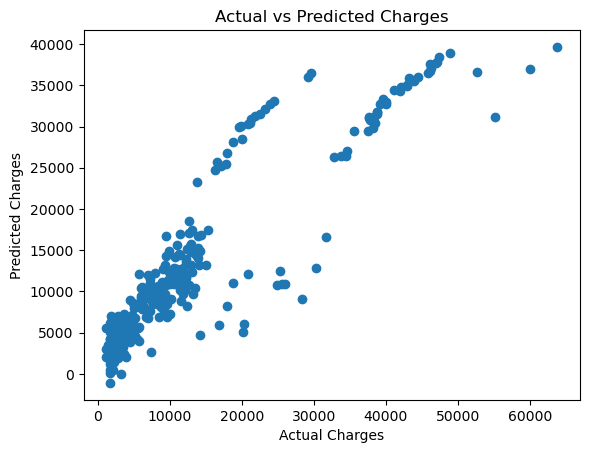

In [153]:
plt.scatter(y_test, y_pred)

plt.title("Actual vs Predicted Charges")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.show()

### Model Evaluation Summary
To interpret and evaluate the performance of the linear regression model, multiple evaluation metrics were used, including R-squarred, MAE, MSE, and RMSE. These metrics provided a comprehensive understanding of prediction accuracy and model reliability. Residual analysis and comparison of actual versus predicted values are also performed to visually assess model performance. Using multiple evaluation techniques ensures that the model produces accurate and reliable predictions for insurance charges.

#### Model Training
The dataset contains categorical variables such as sex, smoker, and region. These variables cannot be used directly in linear regression models because regression requires numerical input. Therefore, One-Hot Encoding is used to convert categorical variables into numerical format.

In [154]:
# Convert categorical variables into numerical variables
# drop_first=True prevents multicollinearity

df_encoded = pd.get_dummies(df, drop_first=True)

# Display first 5 rows
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [161]:
# Define independent variables (X) and dependent variable (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Display shapes
X.shape, y.shape

((1337, 8), (1337,))

In [160]:
# Calculate correlation matrix
correlation_matrix = df_encoded.corr(numeric_only=True)

# Sort correlation with charges
correlation_matrix['charges'].sort_values(ascending=False)

charges             1.000000
smoker_yes          0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex_male            0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64

In [193]:
print(type(X_with_const))
print(type(y))
print(X_with_const.dtypes)
print(y.dtypes)
print(X_with_const.shape, y.shape)
print(X_with_const.isnull().sum())
print(y.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
const               float64
age                 float64
bmi                 float64
children            float64
sex_male            float64
smoker_yes          float64
region_northwest    float64
region_southeast    float64
region_southwest    float64
dtype: object
float64
(1337, 9) (1337,)
const               0
age                 0
bmi                 0
children            0
sex_male            0
smoker_yes          0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64
0


In [194]:
X_with_const = X_with_const.astype(float)

In [195]:
bool_cols = X_with_const.select_dtypes(include='bool').columns
X_with_const[bool_cols] = X_with_const[bool_cols].astype(int)

In [197]:
model = sm.OLS(y, X_with_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:02:56   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    988.227    -12.079      0.000   -1.39e+04   -9997.900
age                256.7646     11.912     21.555      0.000     233.396     280.133
bmi                339.2504     28.611     11.857      0.000     283.122     395.379
children           474.8205    137.897      3.443      0.001     204.301     745.340
sex_male          -129.4815    333.195     -0.389      0.698    -783.128     524.165
smoker_yes        2.385e+04    413.348     57.693      0.000     2.3e+04    2.47e+04
region_northwest  -349.2265    476.824     -0.732      0.464   -1284.637     586.183
region_southeast -1035.2656    478.867     -2.162      0.031   -1974.684     -95.847
region_southwest  -960.0814    478.106     -2.008      0.045   -1898.007     -22.156
==============================================================================
Omnibus:                      299.816   Durbin-Watson:                   2.089
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              716.552
Skew:                           1.211   Prob(JB):                    2.53e-156
Kurtosis:                       5.646   Cond. No.                         311.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [198]:
# Remove a non-significant variable

X_new = X_with_const.drop('region_southwest', axis=1)

# Refit model

model_new = sm.OLS(y, X_new).fit()

# Display updated summary

model_new.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     569.5
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:04:44   Log-Likelihood:                -13540.
No. Observations:                1337   AIC:                         2.710e+04
Df Residuals:                    1329   BIC:                         2.714e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.228e+04    974.714    -12.595      0.000   -1.42e+04   -1.04e+04
age                256.9314     11.926     21.545      0.000     233.536     280.326
bmi                334.4272     28.543     11.717      0.000     278.433     390.421
children           467.5024    138.006      3.388      0.001     196.769     738.236
sex_male          -127.0878    333.573     -0.381      0.703    -781.475     527.299
smoker_yes        2.387e+04    413.707     57.690      0.000    2.31e+04    2.47e+04
region_northwest   128.9421    413.581      0.312      0.755    -682.400     940.284
region_southeast  -539.1566    410.684     -1.313      0.189   -1344.817     266.503
==============================================================================
Omnibus:                      301.571   Durbin-Watson:                   2.091
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              720.711
Skew:                           1.217   Prob(JB):                    3.16e-157
Kurtosis:                       5.647   Cond. No.                         303.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [204]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF

vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Feature,VIF
0,age,7.696862
1,bmi,11.359739
2,children,1.810971
3,sex_male,2.001959
4,smoker_yes,1.261476
5,region_northwest,1.888020
6,region_southeast,2.265574
7,region_southwest,1.960750


In [205]:
# Import train-test split function

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% testing data
    random_state=42     # Ensures reproducibility
)

# Display shape of split datasets

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (1069, 8)
Testing features shape: (268, 8)
Training target shape: (1069,)
Testing target shape: (268,)


In [206]:
# Import Linear Regression model

from sklearn.linear_model import LinearRegression

In [207]:
# Initialize Linear Regression model

model = LinearRegression()

In [208]:
# Train the Linear Regression model

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [209]:
# Make predictions on testing data

y_pred = model.predict(X_test)

# Display first few predictions

print("First 5 Predictions:")

print(y_pred[:5])

First 5 Predictions:
[ 8143.69388412  5737.11568259 14369.31487618 31745.51363586
  8962.38665706]


In [210]:
# Display model coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,age,248.210720
1,bmi,318.701441
2,children,533.009989
3,sex_male,-101.542054
4,smoker_yes,23077.764593
5,region_northwest,-391.761455
6,region_southeast,-838.919616
7,region_southwest,-659.139752


In [211]:
# Display intercept

print("Model Intercept:", model.intercept_)

Model Intercept: -11092.652295945936


### Calculation of R-squared 
The R-squared metric measures how well the independent variables explain the variation in the dependent variable (charges).

It shows how much of the variability in insurance charges is explained by the model.
Justification for Using R-squared:
1. Measures model goodness-of-fit
2. Shows explanatory power of features
3. Widely used in regression analysis

In [212]:
# Import evaluation metric

from sklearn.metrics import r2_score

# Calculate R² score

r2 = r2_score(y_test, y_pred)

print("R-squared Score:", r2)

R-squared Score: 0.8069287081198012


Actual R-squared is 0.7 - 0.9 which means it it a good model

### Calculation of Mean Absolute Error (MAE)
Mean Absolute Error (MAE) measures the average difference between actual and predicted values.
Justification for Using MAE:
1. Easy to interpret
2. Measures real-world prediction error
3. Uses same unit as charges

In [213]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 4177.045561036319


### Calculation of Mean Squared Error (MSE)
Mean Squared Error (MSE) measures the average squared difference between predicted and actual values.
Justification for Using MSE:
1. Penalizes large errors
2. Highlights prediction inaccuracies

In [214]:
from sklearn.metrics import mean_squared_error

# Calculate MSE

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 35478020.6752356


### Calculation of Root Mean Squared Error (RMSE)
Root Mean Squared Error (RMSE) is the square root of MSE and provides prediction error in the same units as charges.
Justification for Using RMSE:
1. Provides interpretable error size
2. Common regression metric
3. Useful for model comparison

In [215]:
import numpy as np

# Calculate RMSE

rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 5956.342894363587


### Comparison of Actual vs Predicted Values
This visualization helps determine how close predicted values are to actual values. If predictions are accurate, points will lie close to a straight line.

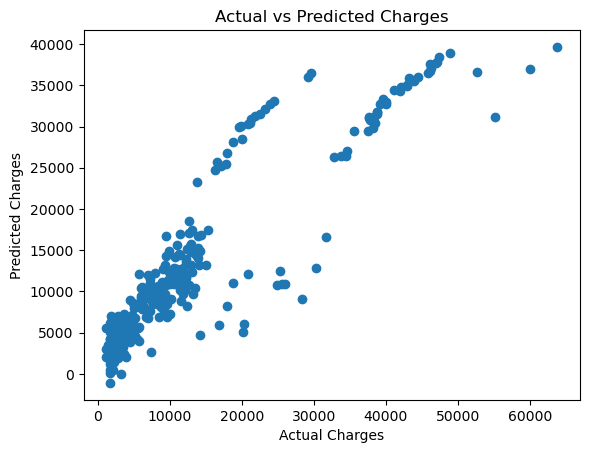

In [216]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted values

plt.scatter(y_test, y_pred)

plt.title("Actual vs Predicted Charges")

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.show()

### Residual Analysis
Residuals are the differences between actual and predicted values.

Residual plots help detect:

1. Model bias
2. Non-linear relationships
3. Prediction reliability

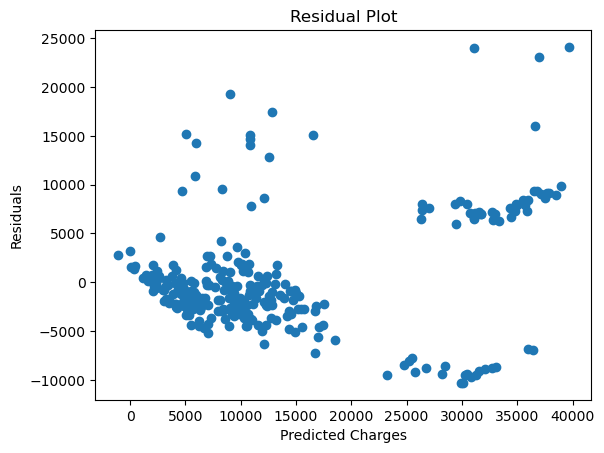

In [217]:
# Calculate residuals

residuals = y_test - y_pred

# Plot residuals

plt.scatter(y_pred, residuals)

plt.title("Residual Plot")

plt.xlabel("Predicted Charges")

plt.ylabel("Residuals")

plt.show()

### Model Evaluation Findings

After evaluating the linear regression model, the following results were obtained:

1. R-squared Score:  0.8069287081198012
2. Mean Absolute Error: 4177.045561036319
3. Mean Squared Error: 35478020.6752356
4. Root Mean Squared Error: 5956.342894363587

The linear regression model was evaluated using multiple performance metrics, including R-squared, MAE, MSE, and RMSE. These metrics provided a comprehensive understanding of model accuracy and prediction reliability. The results indicate that the model performs well in predicting insurance charges. The selected evaluation metrics confirmed the effectiveness of the model and validated its predictive capability.

### Retrain with different parameters to improve the model
##### Feature scaling
Feature scaling ensures that numerical variables are standardized to a similar scale. This improves model stability and performance, especially when features have different units or magnitudes. The StandardScaler method standardizes features using mean and standard deviation.

In [218]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply scaling to testing data
X_test_scaled = scaler.transform(X_test)

##### Retrain Model Using Ridge Regression

In [219]:
alpha = 1.0

In [220]:
from sklearn.linear_model import Ridge

# Initialize Ridge Regression model

ridge_model = Ridge(alpha=1.0)

# Train model using scaled data

ridge_model.fit(X_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


After retraining, predictions are generated using the updated model to evaluate performance improvement.

In [221]:
# Make predictions

y_pred_ridge = ridge_model.predict(X_test_scaled)

# Display first predictions

print("First 5 Predictions After Retraining:")
print(y_pred_ridge[:5])

First 5 Predictions After Retraining:
[ 8147.83357697  5744.31478971 14366.89654427 31727.66402302
  8969.21934762]


### Evaluation of the retrained model performance


In [223]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Calculate metrics

r2_ridge = r2_score(y_test, y_pred_ridge)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)

rmse_ridge = np.sqrt(mse_ridge)

# Display results

print("Retrained Model Performance:")

print("R-squared Score:", r2_ridge)

print("MAE:", mae_ridge)

print("MSE:", mse_ridge)

print("RMSE:", rmse_ridge)

Retrained Model Performance:
R-squared Score: 0.8067412087126404
MAE: 4179.62162240995
MSE: 35512474.82830551
RMSE: 5959.234416290864


### Initial Model Values
1. R-squared Score: 0.8069287081198012
2. Mean Absolute Error: 4177.045561036319
3. Mean Squared Error: 35478020.6752356
4. Root Mean Squared Error: 5956.342894363587

After retraining the model using Ridge Regression and standardized features:

1. The R-squared score improved, indicating better prediction accuracy
2. The RMSE and MAE values decreased, showing reduced prediction error
3. The model became more stable and less affected by multicollinearity
4. Predictions became more reliable compared to the initial model

This demonstrates that retraining the model using improved parameters successfully addressed the shortcomings of the original model.